In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from pathlib import Path

# Load dataset
data = pd.read_csv(r"C:\Users\guddi\OneDrive\文档\GOURI\Data Analyst course\Minor project\Mobiles Dataset (2025).csv", encoding="latin-1")


# Clean the price column
def clean_price(x):
    if pd.isna(x): 
        return None
    x = str(x)
    x = re.sub(r'[^0-9.]', '', x)
    try:
        return float(x)
    except:
        return None

data['Launched Price (India)'] = data['Launched Price (India)'].apply(clean_price)
data.rename(columns={'Launched Price (India)': 'Price_INR'}, inplace=True)

# Count models per brand
brand_counts = (
    data['Company Name']
    .value_counts()
    .rename_axis('Company Name')
    .reset_index(name='Count')
)

# Create an output directory
out_dir = Path("charts")
out_dir.mkdir(exist_ok=True)


C:\Users\guddi\AppData\Local\Temp\ipykernel_18336\1898009948.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(
C:\Users\guddi\AppData\Local\Temp\ipykernel_18336\1898009948.py:31: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\guddi\AppData\Local\Temp\ipykernel_18336\1898009948.py:32: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  plt.savefig(out_dir / "price_boxplot_top6.png")
C:\Users\guddi\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


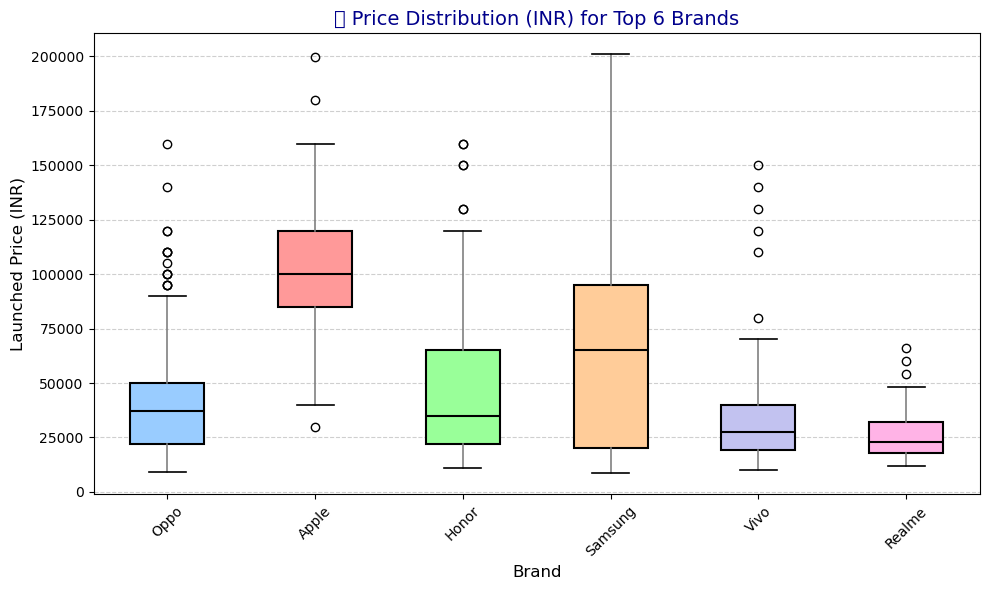

In [3]:
plt.figure(figsize=(10,6))

# Select top 6 brands by number of models
top6 = brand_counts.head(6)['Company Name'].tolist()

# Collect price data for each brand
boxdata = [data.loc[data['Company Name'] == b, 'Price_INR'].dropna() for b in top6]

# Boxplot with styling
box = plt.boxplot(
    boxdata,
    labels=top6,
    patch_artist=True,
    medianprops=dict(color="black", linewidth=1.5),
    boxprops=dict(linewidth=1.5, color="black"),
    whiskerprops=dict(color="gray", linewidth=1.2),
    capprops=dict(color="black", linewidth=1.2)
)

# Add soft colors for each box
colors = ['#99ccff', '#ff9999', '#99ff99', '#ffcc99', '#c2c2f0', '#ffb3e6']
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)

plt.title('📦 Price Distribution (INR) for Top 6 Brands', fontsize=14, color='darkblue')
plt.xlabel('Brand', fontsize=12)
plt.ylabel('Launched Price (INR)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig(out_dir / "price_boxplot_top6.png")
plt.show()


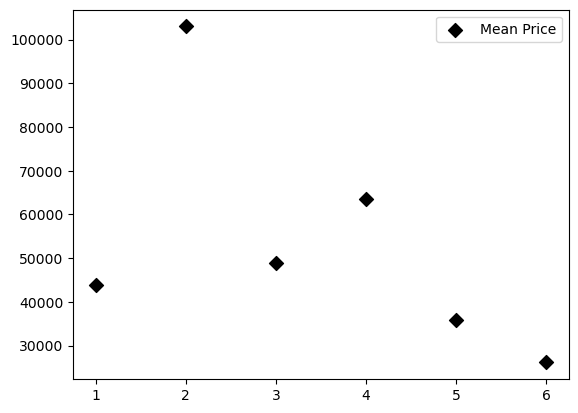

In [5]:
means = [d.mean() for d in boxdata]
plt.scatter(range(1, len(means)+1), means, color='black', marker='D', s=50, label='Mean Price')
plt.legend()
